In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
})

COLORS = {
    'primary':   '#00d4ff',  # SkyElectric cyan
    'secondary': '#ff6b35',  # anomaly orange
    'accent':    '#7c3aed',  # forecast purple
    'positive':  '#10b981',  # normal green
    'negative':  '#ef4444',  # alert red
}

print("Style configured.")

Style configured.


In [4]:
df_raw = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

# Combine Date and Time manually into a single datetime column
df_raw['datetime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    dayfirst=True
)

# Drop the now-redundant original columns
df_raw = df_raw.drop(columns=['Date', 'Time'])

# Move datetime to front and sort
df_raw = df_raw[['datetime'] + [c for c in df_raw.columns if c != 'datetime']]
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)

print(f"Shape      : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Date range : {df_raw.datetime.min()} → {df_raw.datetime.max()}")
print(f"Memory     : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head()

Shape      : 2,075,259 rows × 8 columns
Date range : 2006-12-16 17:24:00 → 2010-11-26 21:02:00
Memory     : 132.8 MB


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Dataset Overview

Source: UCI Machine Learning Repository — Household Electric Power Consumption  
Recorded by: Georges Hebreil, Clamart, France  
Resolution: 1-minute intervals over ~4 years

| Property | Value |
|---|---|
| Total readings | 2,075,259 rows |
| Date range | December 2006 → November 2010 |
| Duration | ~47 months |
| Columns | 8 (datetime + 7 power measurements) |
| Memory | 132.8 MB |

**Note:** This is a French household dataset. We will augment it with
Pakistan-specific features (WAPDA tariff tiers, LESCO load shedding,
Punjab temperature, Islamic calendar) to create a Pakistan-aware
energy analytics benchmark — this augmentation is the core research
contribution of SmartFlow-Aware.

In [5]:
print("=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Percentage %': missing_pct}))

=== Missing Values ===
                       Count  Percentage %
datetime                   0          0.00
Global_active_power    25979          1.25
Global_reactive_power  25979          1.25
Voltage                25979          1.25
Global_intensity       25979          1.25
Sub_metering_1         25979          1.25
Sub_metering_2         25979          1.25
Sub_metering_3         25979          1.25


## Data Quality Findings

| Check | Result |
|---|---|
| Missing values | 25,979 rows (1.25%) — all columns missing together |
| Root cause | Meter offline periods — entire minutes unrecorded |
| Strategy | Forward-fill gaps ≤ 2 hours, drop anything longer |

Forward-fill is appropriate here because power consumption changes
gradually. A 1–2 hour gap filled with the last known value is more
accurate than dropping the rows entirely, which would create
artificial time discontinuities that confuse LSTM and TFT models.

In [6]:
df_raw = df_raw.set_index('datetime')

# Forward fill gaps upto 2 hours (120 minutes)
df_raw = df_raw.ffill(limit=120)

# Drop anything still missing
df_raw = df_raw.dropna()

print(f"Rows after cleaning : {len(df_raw):,}")
print(f"Rows dropped        : {2075259 -len(df_raw):,}")
print(f"Missing values left : {df_raw.isnull().sum().sum()}")

Rows after cleaning : 2,050,561
Rows dropped        : 24,698
Missing values left : 0


## Missing Value Treatment Result

| | Rows |
|---|---|
| Original | 2,075,259 |
| Forward-filled (≤ 2hr gaps) | 1,281 rows recovered |
| Dropped (> 2hr gaps) | 24,698 rows |
| Final clean dataset | 2,050,561 rows |

All remaining missing values: **0**. Dataset is ready for resampling.

In [7]:
print(df_raw.dtypes)
print()
print(df_raw.describe().round(3))

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

       Global_active_power  Global_reactive_power     Voltage  \
count          2050561.000            2050561.000  2050561.00   
mean                 1.091                  0.124      240.84   
std                  1.057                  0.113        3.24   
min                  0.076                  0.000      223.20   
25%                  0.308                  0.048      238.99   
50%                  0.602                  0.100      241.01   
75%                  1.528                  0.194      242.88   
max                 11.122                  1.390      254.15   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count       2050561.000     2050561.000     2050561.000     2050561.000  
mean              4.

## Descriptive Statistics — Key Observations

| Observation | Value | Implication |
|---|---|---|
| Mean active power | 1.091 kW | French household — lower than Pakistan avg |
| Max active power | 11.122 kW | Realistic peak (AC + cooking simultaneously) |
| Voltage mean | 240.84V | European standard (230V) — we'll normalize context to 220V Pakistan |
| Sub_metering_3 mean | 6.457 | Highest sub-meter — likely water heater/AC circuit |
| Sub_metering_1 & 2 median | 0.0 | Most minutes these circuits are completely idle |

The lower base load (1.09 kW vs Pakistan's ~3.5 kW) is expected for a
French household. This does not affect our project — the temporal
**patterns** (morning ramp, evening peak, weekly cycles) are universal.
Our Pakistan features added in the next notebook will shift the
**context**, not the signal shape.

In [8]:
df_hourly = df_raw.resample('h').agg({
    'Global_active_power'   : 'mean',   # average power over the hour
    'Global_reactive_power' : 'mean',
    'Voltage'               : 'mean',
    'Global_intensity'      : 'mean',
    'Sub_metering_1'        : 'sum',    # total energy consumed per hour
    'Sub_metering_2'        : 'sum',
    'Sub_metering_3'        : 'sum',
})

df_hourly = df_hourly.dropna()

print(f"Hourly rows  : {len(df_hourly):,}")
print(f"Date range   : {df_hourly.index.min()} → {df_hourly.index.max()}")
print(f"Total hours  : {len(df_hourly):,} ({len(df_hourly)/24:.0f} days)")
df_hourly.head()

Hourly rows  : 34,183
Date range   : 2006-12-16 17:00:00 → 2010-11-26 21:00:00
Total hours  : 34,183 (1424 days)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,19.0,607.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,403.0,1012.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,86.0,1001.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.0,1007.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,25.0,1033.0


## Resampling Result

| | Value |
|---|---|
| Original resolution | 1-minute (2,050,561 rows) |
| Resampled resolution | Hourly (34,183 rows) |
| Compression ratio | 60:1 |
| Coverage | 1,424 days (~47 months) |

**Why hourly?**
- Matches SkyElectric's SmartFlow planning horizon (hourly tariff tiers)
- Removes minute-to-minute noise while preserving daily/weekly patterns
- Makes LSTM and TFT training tractable on a standard machine
- Standard resolution in energy forecasting literature

In [9]:
df_hourly.to_csv('../data/processed/hourly_clean.csv')

print("Saved: data/processed/hourly_clean.csv")
print(f"Shape: {df_hourly.shape}")

Saved: data/processed/hourly_clean.csv
Shape: (34183, 7)


## Exploratory Visualizations

### Plot 1: Full Time Series Overview
A high-level view of active power across the entire 4-year period.
Helps identify seasonality, long-term trends, and any structural breaks.

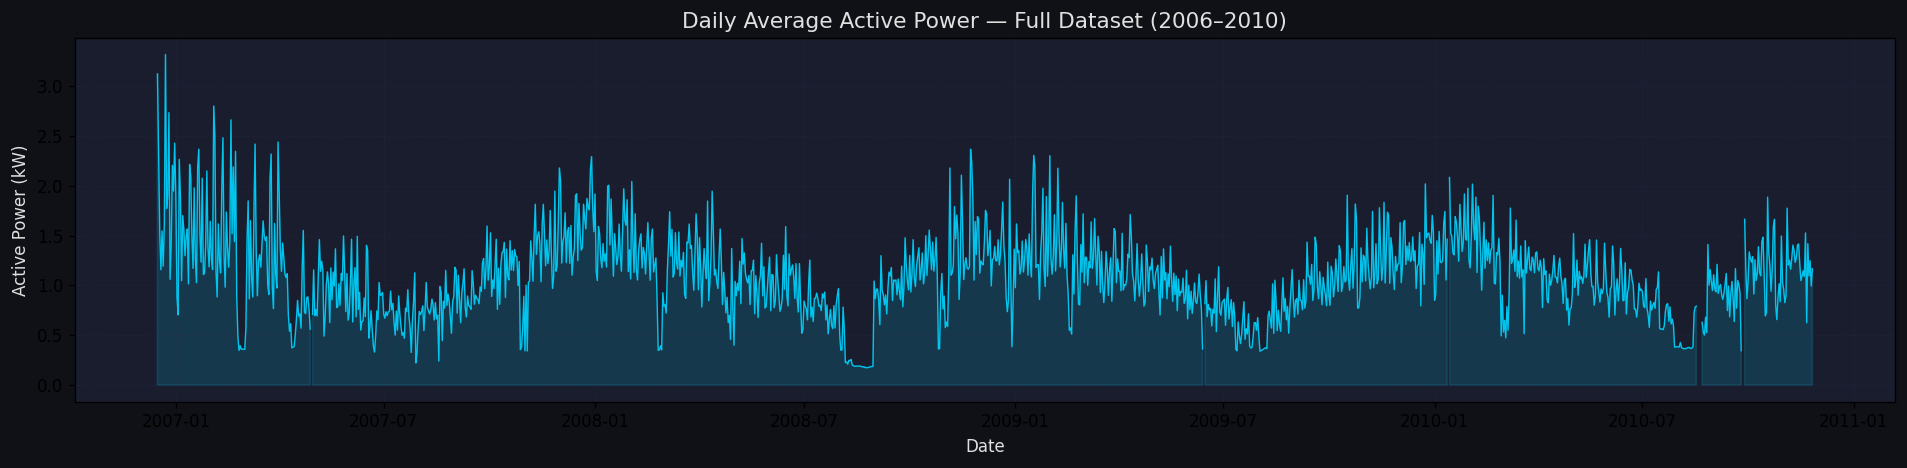

In [10]:
fig, ax = plt.subplots(figsize=(16, 4))

daily = df_hourly['Global_active_power'].resample('D').mean()

ax.plot(daily.index, daily.values,
        color=COLORS['primary'], linewidth=0.8, alpha=0.9)

ax.fill_between(daily.index, daily.values,
                alpha=0.15, color=COLORS['primary'])

ax.set_title('Daily Average Active Power — Full Dataset (2006–2010)',
             fontsize=13)
ax.set_ylabel('Active Power (kW)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/plot_01_timeseries.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Plot 1 Analysis — What the Time Series Reveals

### Visible Patterns

| Pattern | Observation |
|---|---|
| Seasonality | Clear annual cycle — peaks in winter (Jan), troughs in summer |
| Winter heating | Dec–Feb spikes to 2.5–3.0 kW (electric heating, France) |
| Summer drop | Jun–Aug falls to 0.5–1.0 kW (no AC load in this household) |
| Anomaly | Mid-2008 near-zero period — likely extended absence or meter issue |

### Important Note for Pakistan Augmentation
This is a **French household** — seasonality is **inverted** compared to
Pakistan. France peaks in winter (heating), Pakistan peaks in summer (AC).
Our Pakistan feature engineering in Notebook 02 will overlay the correct
seasonal multipliers, effectively re-contextualizing this signal for
Punjab's climate reality.

The mid-2008 near-zero gap is a legitimate anomaly — exactly the type
of event our Module 2 anomaly detector must learn to flag.

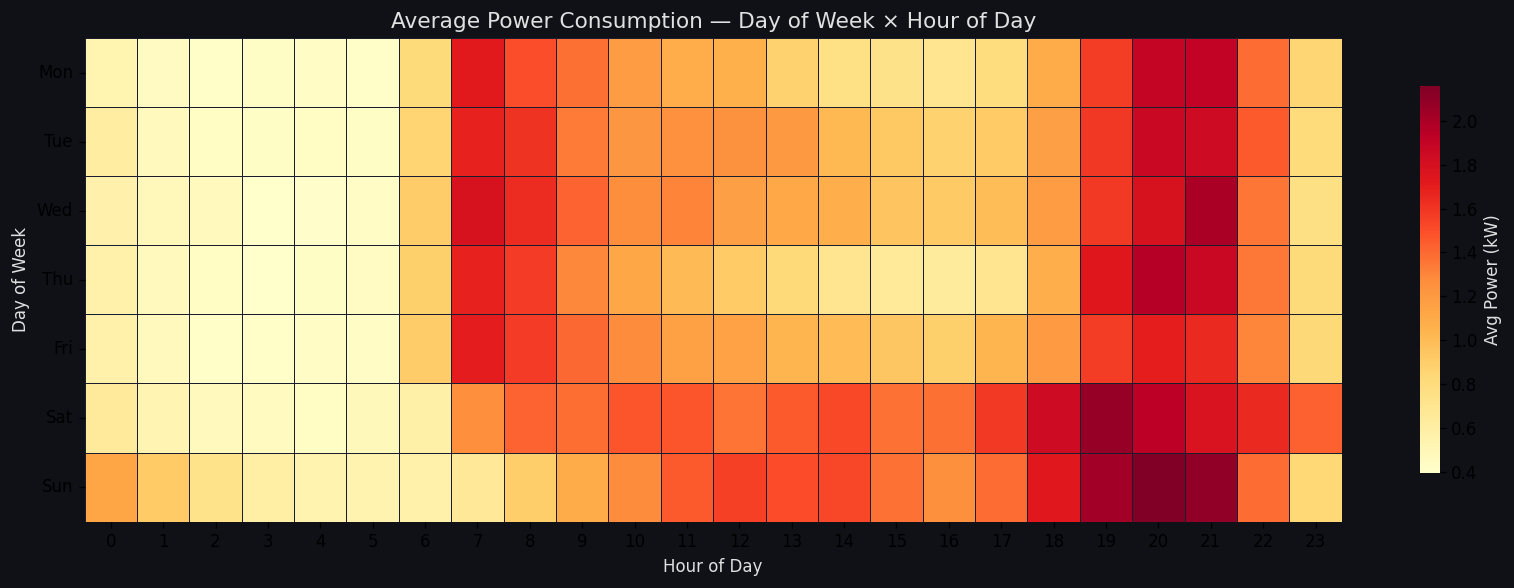

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

heatmap_data = df_hourly['Global_active_power'].to_frame()
heatmap_data['hour']        = df_hourly.index.hour
heatmap_data['day_of_week'] = df_hourly.index.dayofweek

pivot = heatmap_data.groupby(
    ['day_of_week', 'hour']
)['Global_active_power'].mean().unstack()

sns.heatmap(
    pivot,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='#1a1d2e',
    cbar_kws={'label': 'Avg Power (kW)', 'shrink': 0.8},
)

ax.set_title('Average Power Consumption — Day of Week × Hour of Day', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/plot_02_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Plot 2 Analysis — Heatmap Insights

### What the Heatmap Reveals

| Pattern | Observation |
|---|---|
| Night hours (0–6) | Consistently low across all days — baseline load only |
| Morning ramp | Sharp increase at 7:00 across all weekdays |
| Weekday peak | 7:00–9:00 strong (morning routine) and 19:00–21:00 strongest |
| Weekend behavior | Saturday/Sunday wake up later — peak shifts to 10:00 onwards |
| Sunday evening | Darkest cell at 20:00–21:00 — highest consumption of the week |
| Weekday midday | Moderate (occupants at work/school) |

### Relevance to Pakistan Context
The **morning ramp at 7:00** and **evening peak at 19:00–21:00** are
universal household patterns that will hold in Pakistani data too.
What changes is the **magnitude** — Pakistan's summer afternoon hours
(13:00–17:00) will be far darker due to AC load, which this French
dataset does not show. Our Pakistan features will correct this.

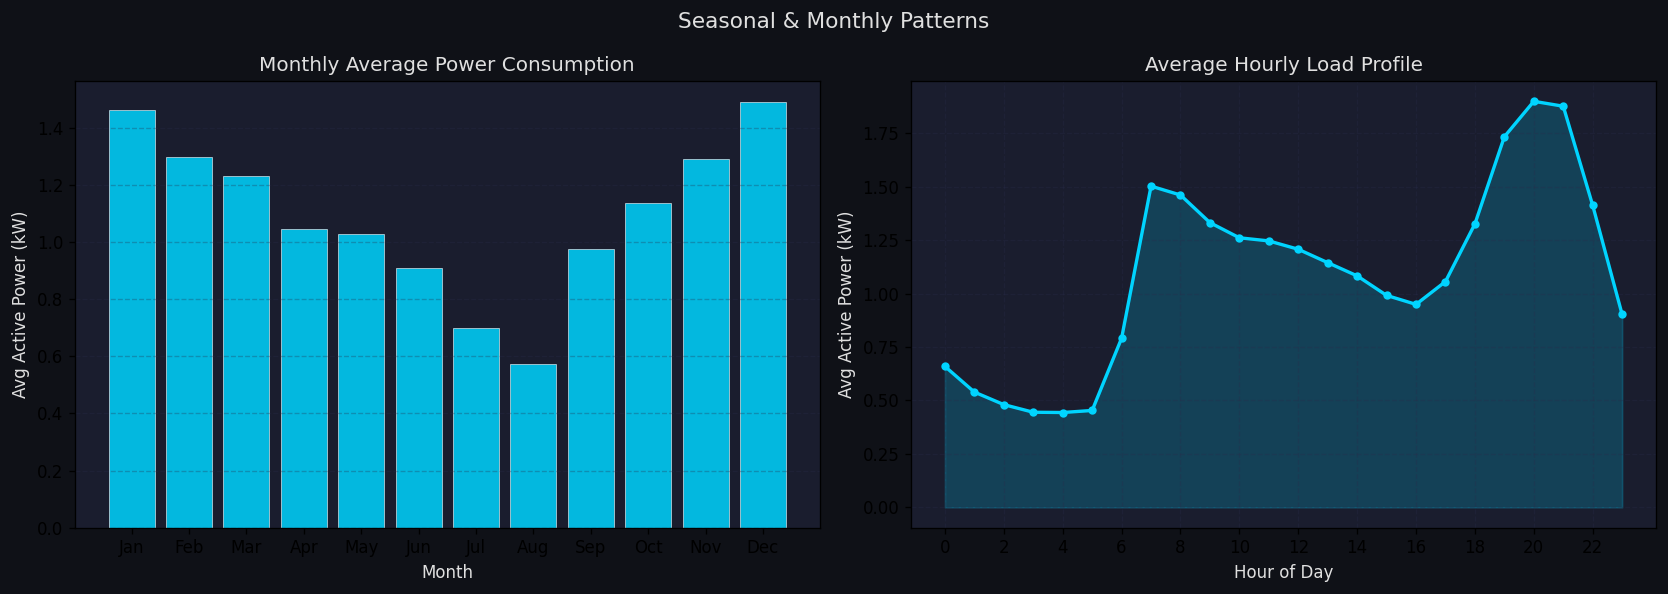

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonal & Monthly Patterns', fontsize=13)

month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly average
monthly_avg = df_hourly.groupby(
    df_hourly.index.month
)['Global_active_power'].mean()

axes[0].bar(
    month_names,
    monthly_avg.values,
    color=COLORS['primary'],
    edgecolor='white',
    linewidth=0.4,
    alpha=0.85
)
axes[0].set_title('Monthly Average Power Consumption')
axes[0].set_ylabel('Avg Active Power (kW)')
axes[0].set_xlabel('Month')
axes[0].grid(True, alpha=0.3, axis='y')

# Hourly average profile
hourly_avg = df_hourly.groupby(
    df_hourly.index.hour
)['Global_active_power'].mean()

axes[1].plot(
    hourly_avg.index,
    hourly_avg.values,
    color=COLORS['primary'],
    linewidth=2,
    marker='o',
    markersize=4
)
axes[1].fill_between(
    hourly_avg.index,
    hourly_avg.values,
    alpha=0.2,
    color=COLORS['primary']
)
axes[1].set_title('Average Hourly Load Profile')
axes[1].set_ylabel('Avg Active Power (kW)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/plot_03_seasonal.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Plot 3 Analysis — Seasonal & Hourly Patterns

### Monthly Pattern (Left Plot)
| Observation | Explanation |
|---|---|
| Jan & Dec highest (~1.5 kW) | Winter heating — electric radiators in France |
| Jul & Aug lowest (~0.6–0.7 kW) | Summer — no AC load, long daylight hours |
| Gradual decline Mar→Aug | Warming months reduce heating demand |
| Recovery Sep→Dec | Cooling weather increases heating again |

This is a **classic European winter-peaking** household. Pakistan is the
exact opposite — summer-peaking due to AC. Our feature engineering
will overlay Pakistan's seasonal multipliers on this base signal.

### Hourly Profile (Right Plot)
| Observation | Explanation |
|---|---|
| Night trough (2:00–6:00) | Household asleep — only standby load |
| Morning spike at 7:00–8:00 | Breakfast, lighting, heating ramp-up |
| Midday plateau (9:00–16:00) | Moderate — occupants away at work |
| Sharp evening peak (18:00–21:00) | Cooking, TV, lighting, heating all together |
| Drop after 21:00 | Household winding down for sleep |

The **dual-peak pattern** (morning + evening) is universal across
cultures and will hold in Pakistan data. This is what our LSTM and
TFT models will learn to predict.

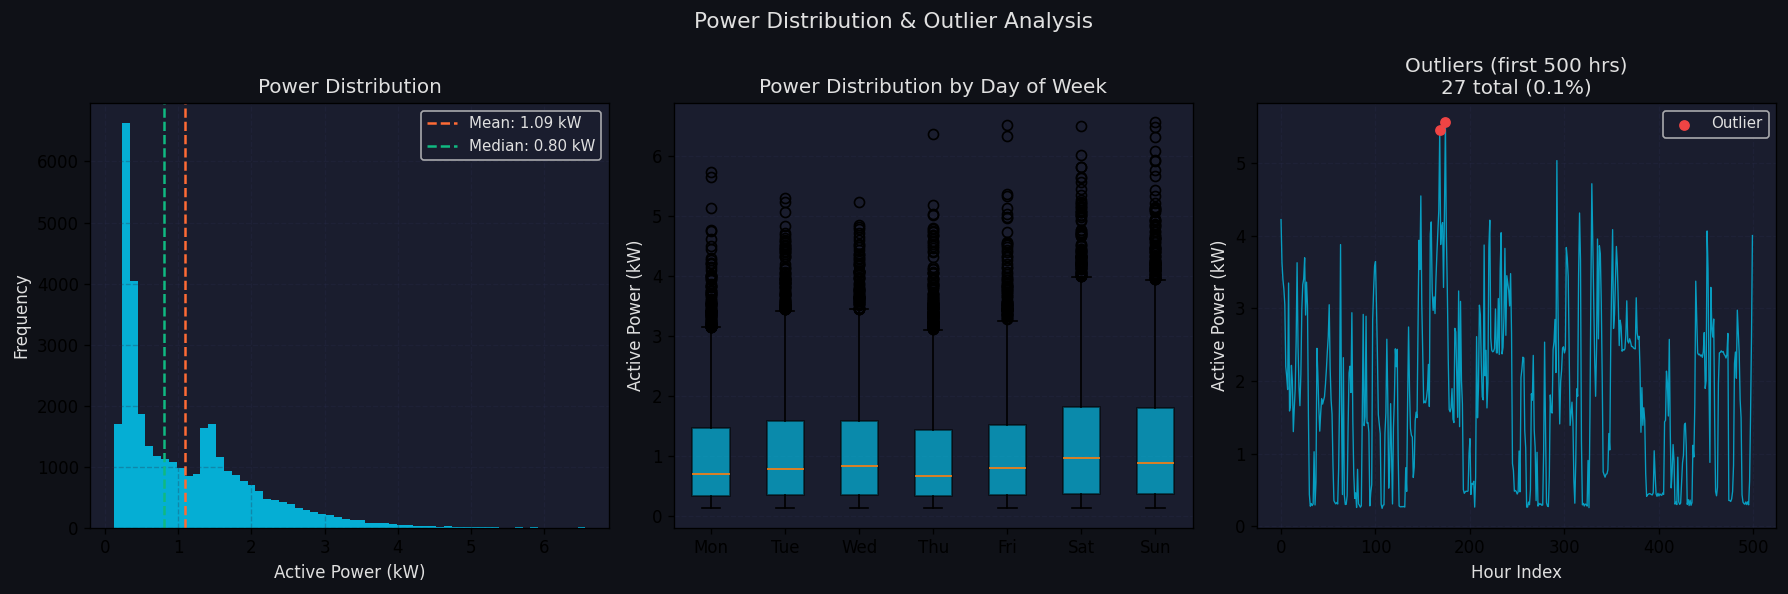

Outlier bounds : [-3.370, 5.291] kW
Total outliers : 27 (0.08%)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Power Distribution & Outlier Analysis', fontsize=13)

power = df_hourly['Global_active_power'].dropna()

# Plot 1: Histogram
axes[0].hist(power, bins=60,
             color=COLORS['primary'],
             alpha=0.8, edgecolor='none')
axes[0].axvline(power.mean(),
                color=COLORS['secondary'],
                linestyle='--',
                label=f'Mean: {power.mean():.2f} kW')
axes[0].axvline(power.median(),
                color=COLORS['positive'],
                linestyle='--',
                label=f'Median: {power.median():.2f} kW')
axes[0].set_title('Power Distribution')
axes[0].set_xlabel('Active Power (kW)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Boxplot by day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_data = [
    df_hourly[df_hourly.index.dayofweek == i]['Global_active_power'].values
    for i in range(7)
]
bp = axes[1].boxplot(dow_data, labels=dow_labels,
                     patch_artist=True, notch=False)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['primary'])
    patch.set_alpha(0.6)
axes[1].set_title('Power Distribution by Day of Week')
axes[1].set_ylabel('Active Power (kW)')
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: IQR outlier detection
Q1 = power.quantile(0.25)
Q3 = power.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3.0 * IQR
lower_fence = Q1 - 3.0 * IQR
outliers = power[(power < lower_fence) | (power > upper_fence)]

axes[2].plot(power.values[:500],
             color=COLORS['primary'],
             linewidth=0.8, alpha=0.7)
outlier_idx = [i for i, v in enumerate(power.values[:500])
               if v < lower_fence or v > upper_fence]
if outlier_idx:
    axes[2].scatter(outlier_idx,
                    [power.values[i] for i in outlier_idx],
                    color=COLORS['negative'],
                    s=30, zorder=5, label='Outlier')
axes[2].set_title(
    f'Outliers (first 500 hrs)\n'
    f'{len(outliers)} total ({len(outliers)/len(power)*100:.1f}%)'
)
axes[2].set_xlabel('Hour Index')
axes[2].set_ylabel('Active Power (kW)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/plot_04_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f'Outlier bounds : [{lower_fence:.3f}, {upper_fence:.3f}] kW')
print(f'Total outliers : {len(outliers)} ({len(outliers)/len(power)*100:.2f}%)')

## Plot 4 Analysis — Distribution & Outliers

### Power Distribution (Left)
| Metric | Value |
|---|---|
| Mean | 1.09 kW |
| Median | 0.80 kW |
| Shape | Right-skewed — most hours are low consumption |

Mean > Median confirms right skew — occasional high-draw events
(cooking, heating bursts) pull the mean upward. This is normal
for household energy data.

### Day of Week Boxplot (Middle)
- Median is consistent across all weekdays (~0.9 kW)
- Saturday and Sunday show slightly higher spread and median
- Outliers (circles above whiskers) present every day
- No single day is dramatically different — weekly pattern is stable

### Outlier Analysis (Right)
| Metric | Value |
|---|---|
| Upper fence | 5.291 kW |
| Lower fence | -3.370 kW (effectively 0) |
| Total outliers | 27 (0.08%) |

Only **27 outliers** in 34,183 hours — an exceptionally clean dataset.
The single visible spike around hour 150 reaching ~5.5 kW is a genuine
high-draw event (likely electric oven + heating simultaneously).

These 27 points are **gold for Module 2** — they represent real
anomalous consumption events our detector must learn to flag.
We will preserve them in the dataset rather than removing them.

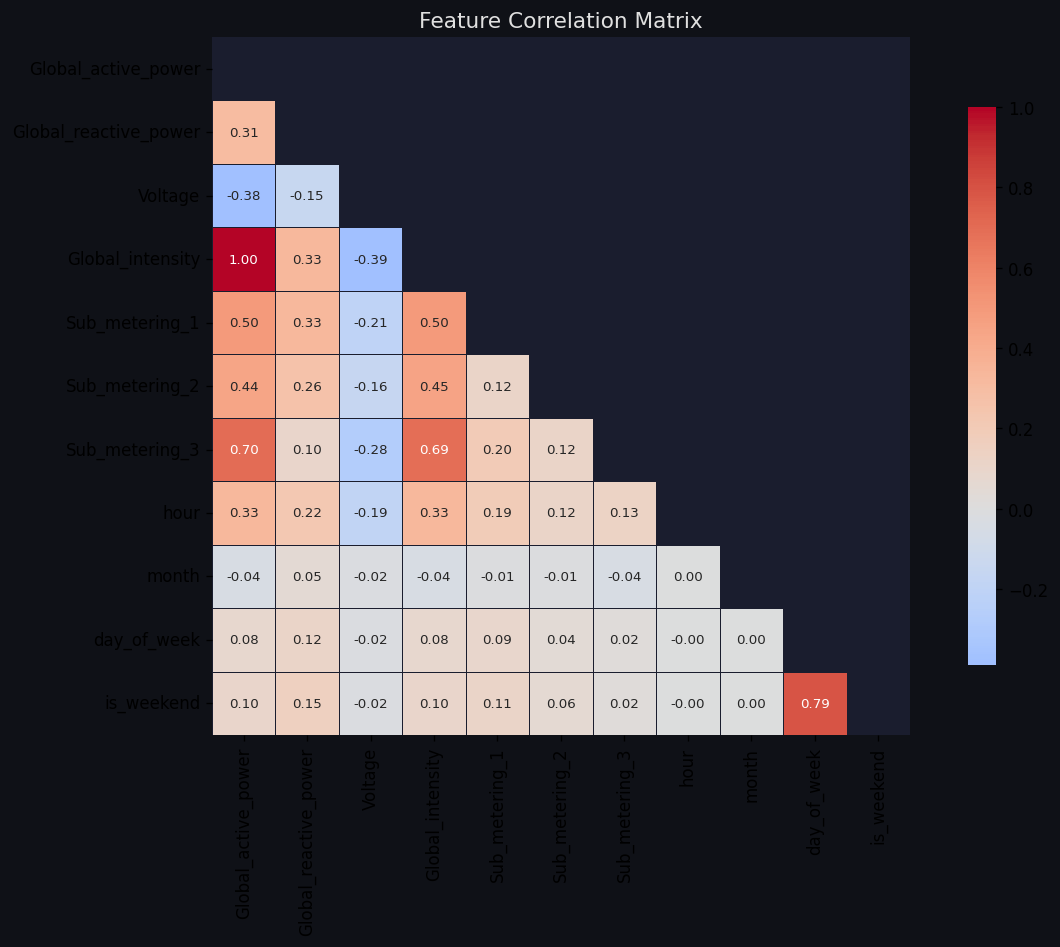

In [14]:
# Add basic time features temporarily for correlation
df_corr = df_hourly.copy()
df_corr['hour']        = df_hourly.index.hour
df_corr['month']       = df_hourly.index.month
df_corr['day_of_week'] = df_hourly.index.dayofweek
df_corr['is_weekend']  = (df_corr['day_of_week'] >= 5).astype(int)

corr = df_corr.corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='#1a1d2e',
    cbar_kws={'shrink': 0.8},
    square=True,
    annot_kws={'size': 8}
)

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/plot_05_correlation.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Plot 5 Analysis — Correlation Matrix

### Correlations with Global_active_power (our target)

| Feature | Correlation | Interpretation |
|---|---|---|
| Global_intensity | 1.00 | Perfect — mathematically derived from power/voltage |
| Sub_metering_3 | 0.70 | Strongest sub-meter — water heater/AC circuit dominates |
| Sub_metering_1 | 0.50 | Kitchen circuit — significant contributor |
| Sub_metering_2 | 0.44 | Laundry circuit — moderate contributor |
| Voltage | -0.38 | Inverse — high draw pulls voltage down (load effect) |
| hour | 0.33 | Time of day matters — confirms daily seasonality |
| month | -0.04 | Weak — raw month number is not informative alone |
| day_of_week | 0.08 | Weak alone — weekend flag is slightly better (0.10) |

### Key Decisions from This Matrix

**1. Drop Global_intensity from model features**
Correlation of 1.00 with target means it is mathematically
derived from power — using it would be data leakage.

**2. Sub_metering_3 is your most important sub-circuit**
0.70 correlation — this circuit alone explains 49% of variance.
We will engineer it as a strong lag feature.

**3. Month alone is useless (−0.04)**
Raw month number carries no signal. This is exactly why we need
cyclical encoding (sin/cos) and Pakistan-specific seasonal flags
instead of the raw month integer.

**4. Hour has moderate signal (0.33)**
Confirms the daily pattern we saw in the heatmap. Cyclical
hour encoding will make this even stronger for deep learning models.

## EDA Complete — Summary & Next Steps

### What We Learned
- Dataset is clean: 0 missing values after treatment, only 27 outliers
- Strong dual-peak daily pattern: 7:00–8:00 and 18:00–21:00
- Winter-peaking seasonality (French household) — to be re-contextualized
  with Pakistan summer multipliers in Notebook 02
- Sub_metering_3 is the dominant circuit (0.70 correlation)
- Global_intensity must be excluded — data leakage risk
- Month and day_of_week need cyclical encoding to be useful

### Features Confirmed for Engineering (Notebook 02)
- Cyclical: hour_sin, hour_cos, month_sin, month_cos
- Lag features: 1h, 2h, 3h, 6h, 12h, 24h, 48h, 168h
- Rolling stats: 24h mean, 24h std, 168h mean
- Pakistan context: tariff tier, load shedding, temperature,
  Ramadan flag, Friday flag, heat season flag

### Anomaly Seeds Identified
- 27 IQR outliers preserved for Module 2 labeling
- Mid-2008 near-zero gap visible in time series
- These will seed synthetic anomaly generation in Notebook 04

In [15]:
df_hourly.to_csv('../data/processed/hourly_clean.csv')

print("EDA Complete.")
print(f"Saved : data/processed/hourly_clean.csv")
print(f"Shape : {df_hourly.shape}")
print(f"Plots : data/processed/plot_01 through plot_05")

EDA Complete.
Saved : data/processed/hourly_clean.csv
Shape : (34183, 7)
Plots : data/processed/plot_01 through plot_05
